# Analise de Precos - Supermercados RJ

Analise de dados coletados automaticamente:
- **Guanabara** (HTML scraping)
- **Zona Sul** (GraphQL VTEX)
- **Atacadao** (VTEX Catalog API)
- **Prezunic** (VTEX Catalog API)
- **Pao de Acucar** (GPA/Linx API)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

## 1. Carregamento dos Dados

In [2]:
def carregar_guanabara():
    df = pd.read_csv('guanabara.txt', sep=';', encoding='latin-1')
    df['preco'] = df['preco'].str.replace(',', '.').astype(float)
    df['data'] = pd.to_datetime(df['data'])
    df['supermercado'] = 'Guanabara'
    return df

def carregar_vtex(prefixo, nome):
    arquivos = sorted(glob.glob(f'{prefixo}_*.txt'))
    if not arquivos:
        return pd.DataFrame()
    dfs = []
    for f in arquivos:
        d = pd.read_csv(f, sep=';', encoding='latin-1')
        dfs.append(d)
        print(f'  {f}: {len(d):,} registros')
    df = pd.concat(dfs, ignore_index=True)
    df['preco'] = pd.to_numeric(df['preco'], errors='coerce')
    df['data'] = pd.to_datetime(df['data'])
    df['supermercado'] = nome
    return df

def carregar_paodeacucar():
    arquivos = sorted(glob.glob('paodeacucar_*.txt'))
    if not arquivos:
        return pd.DataFrame()
    dfs = []
    for f in arquivos:
        d = pd.read_csv(f, sep=';', encoding='latin-1')
        dfs.append(d)
        print(f'  {f}: {len(d):,} registros')
    df = pd.concat(dfs, ignore_index=True)
    df['preco'] = pd.to_numeric(df['preco'], errors='coerce')
    df['data'] = pd.to_datetime(df['data'])
    df['supermercado'] = 'Pao de Acucar'
    return df

print('Carregando dados...')
guanabara = carregar_guanabara()
print(f'Guanabara: {len(guanabara):,} registros')

zsul = carregar_vtex('zsul', 'Zona Sul')
print(f'Zona Sul: {len(zsul):,} registros')

atacadao = carregar_vtex('atacadao', 'Atacadao')
print(f'Atacadao: {len(atacadao):,} registros')

prezunic = carregar_vtex('prezunic', 'Prezunic')
print(f'Prezunic: {len(prezunic):,} registros')

paodeacucar = carregar_paodeacucar()
print(f'Pao de Acucar: {len(paodeacucar):,} registros')

todos = pd.concat([guanabara, zsul, atacadao, prezunic, paodeacucar], ignore_index=True)
print(f'\nTOTAL: {len(todos):,} registros')

Carregando dados...
Guanabara: 107,994 registros
  zsul_202601.txt: 667 registros
  zsul_202602.txt: 1,354 registros
  zsul_202603.txt: 1,446 registros
  zsul_202604.txt: 1,443 registros
  zsul_202605.txt: 1,008 registros
  zsul_202608.txt: 5,824 registros
Zona Sul: 11,742 registros
  atacadao_202608.txt: 23,110 registros


Atacadao: 23,110 registros
  prezunic_202608.txt: 9,836 registros
Prezunic: 9,836 registros
  paodeacucar_202608.txt: 11,376 registros
Pao de Acucar: 11,376 registros

TOTAL: 164,058 registros


## 2. Visao Geral

In [3]:
resumo = []
for nome in ['Guanabara', 'Zona Sul', 'Atacadao', 'Prezunic', 'Pao de Acucar']:
    df = todos[todos['supermercado'] == nome]
    if len(df) == 0:
        continue
    resumo.append({
        'Supermercado': nome,
        'Registros': len(df),
        'Produtos': df['produto'].nunique(),
        'Preco Medio': df['preco'].mean(),
        'Preco Mediana': df['preco'].median(),
        'Min': df['preco'].min(),
        'Max': df['preco'].max(),
    })

df_resumo = pd.DataFrame(resumo)
df_resumo.style.format({
    'Registros': '{:,.0f}', 'Produtos': '{:,.0f}',
    'Preco Medio': 'R$ {:.2f}', 'Preco Mediana': 'R$ {:.2f}',
    'Min': 'R$ {:.2f}', 'Max': 'R$ {:.2f}'
})

,Supermercado,Registros,Produtos,Preco Medio,Preco Mediana,Min,Max
0,Guanabara,"107,994",625,R$ 17.44,R$ 11.98,R$ 0.69,R$ 202.95
1,Zona Sul,"11,742","5,921",R$ 32.49,R$ 12.99,R$ 0.75,R$ 5899.99
2,Atacadao,"23,110","22,280",R$ 1.39,R$ 0.00,R$ 0.00,R$ 549.00
3,Prezunic,"9,836","9,808",R$ 6.51,R$ 0.00,R$ 0.00,R$ 1319.90
4,Pao de Acucar,"11,376","11,335",R$ 36.70,R$ 18.99,R$ 0.99,R$ 2549.90


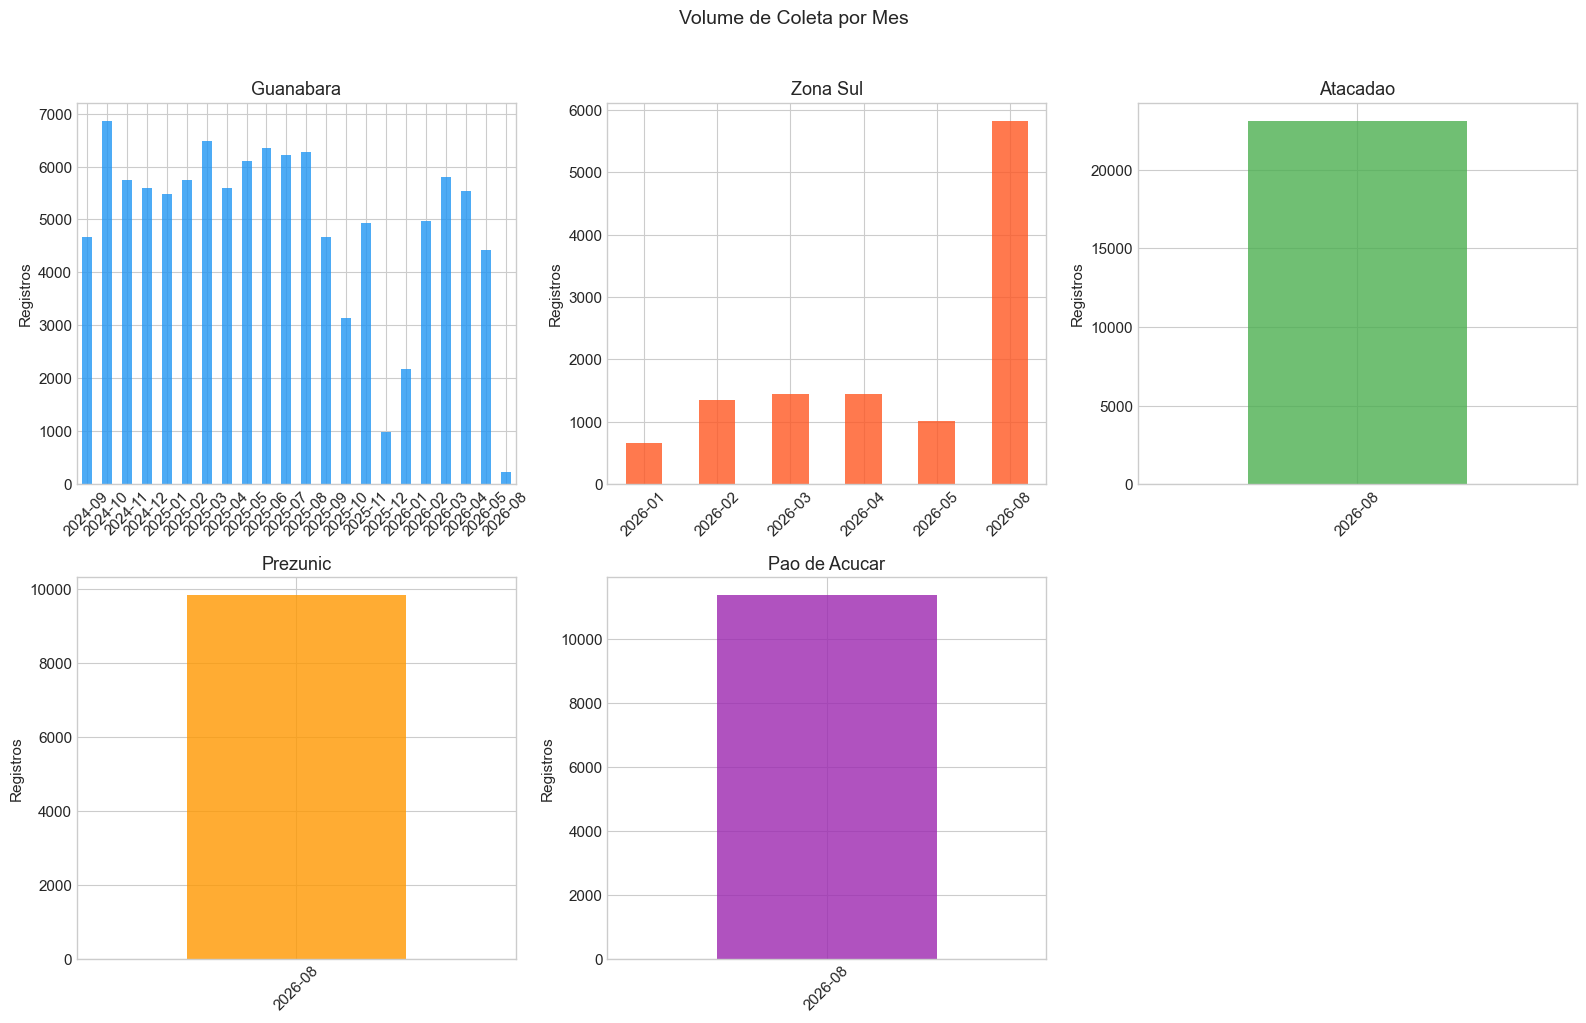

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cores = {'Guanabara': '#2196F3', 'Zona Sul': '#FF5722', 'Atacadao': '#4CAF50',
         'Prezunic': '#FF9800', 'Pao de Acucar': '#9C27B0'}

for idx, nome in enumerate(['Guanabara', 'Zona Sul', 'Atacadao', 'Prezunic', 'Pao de Acucar']):
    ax = axes[idx // 3, idx % 3]
    df = todos[todos['supermercado'] == nome]
    if len(df) == 0:
        ax.set_visible(False)
        continue
    df['mes'] = df['data'].dt.to_period('M')
    df.groupby('mes').size().plot(kind='bar', ax=ax, color=cores[nome], alpha=0.8)
    ax.set_title(nome)
    ax.set_xlabel('')
    ax.set_ylabel('Registros')
    ax.tick_params(axis='x', rotation=45)

axes[1, 2].set_visible(False)
plt.suptitle('Volume de Coleta por Mes', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Distribuicao de Precos

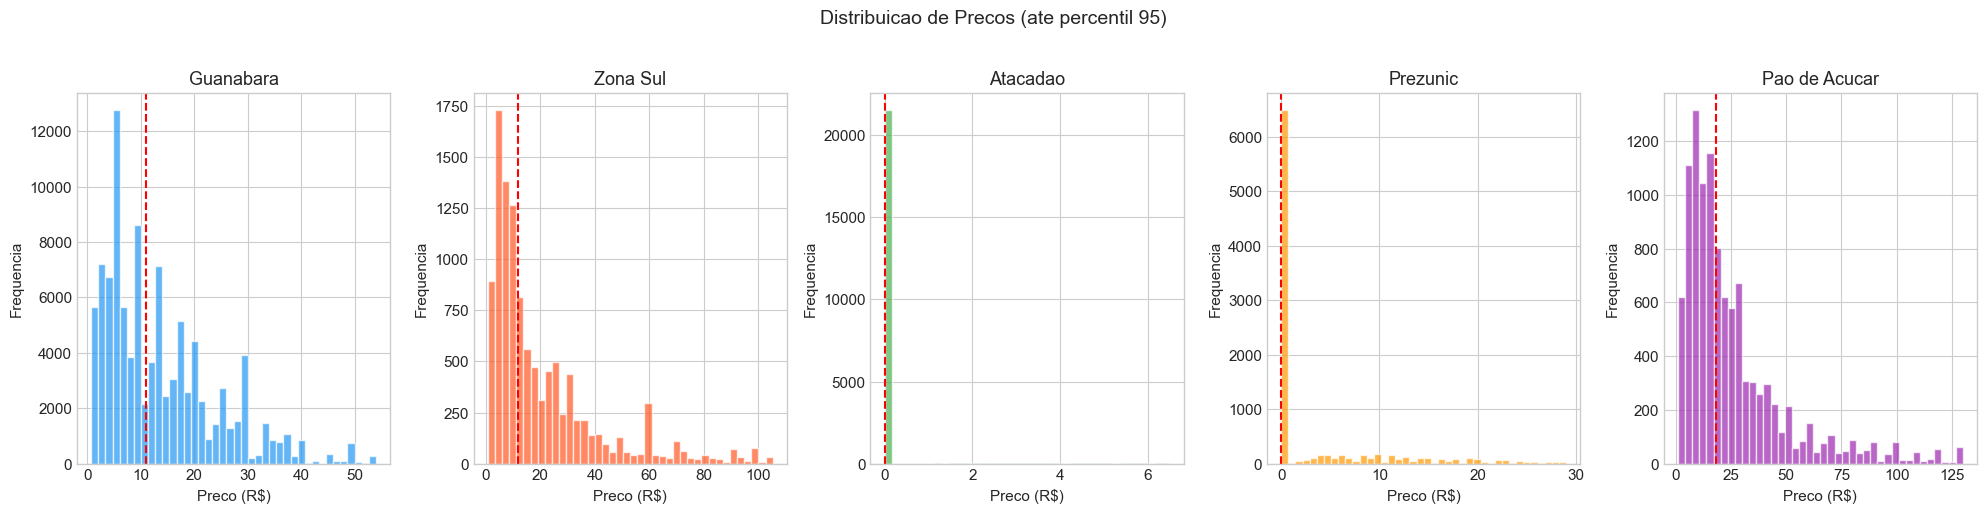

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for idx, nome in enumerate(['Guanabara', 'Zona Sul', 'Atacadao', 'Prezunic', 'Pao de Acucar']):
    df = todos[todos['supermercado'] == nome]
    if len(df) == 0:
        axes[idx].set_visible(False)
        continue
    df_f = df[df['preco'] <= df['preco'].quantile(0.95)]
    axes[idx].hist(df_f['preco'], bins=40, color=cores[nome], alpha=0.7, edgecolor='white')
    axes[idx].axvline(df_f['preco'].median(), color='red', linestyle='--', lw=1.5)
    axes[idx].set_title(nome)
    axes[idx].set_xlabel('Preco (R$)')
    axes[idx].set_ylabel('Frequencia')

plt.suptitle('Distribuicao de Precos (ate percentil 95)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Comparacao entre Supermercados

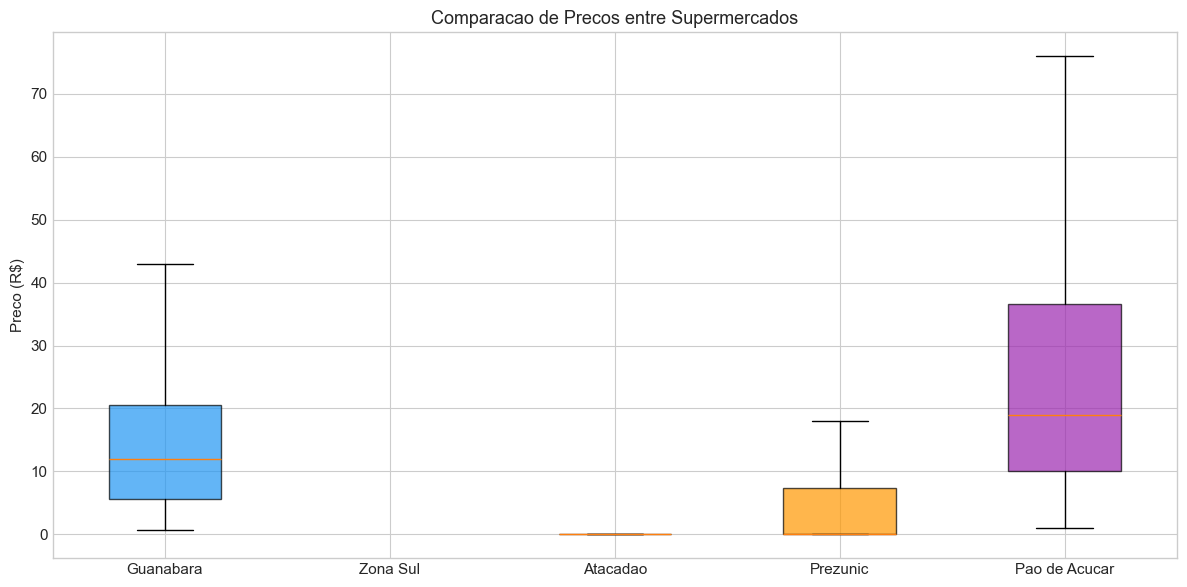

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
dados_box = [todos[todos['supermercado'] == n]['preco'].clip(upper=todos[todos['supermercado'] == n]['preco'].quantile(0.95))
             for n in ['Guanabara', 'Zona Sul', 'Atacadao', 'Prezunic', 'Pao de Acucar']
             if len(todos[todos['supermercado'] == n]) > 0]
nomes_box = [n for n in ['Guanabara', 'Zona Sul', 'Atacadao', 'Prezunic', 'Pao de Acucar']
             if len(todos[todos['supermercado'] == n]) > 0]

bp = ax.boxplot(dados_box, labels=nomes_box, patch_artist=True, showfliers=False)
for patch, nome in zip(bp['boxes'], nomes_box):
    patch.set_facecolor(cores[nome])
    patch.set_alpha(0.7)

ax.set_title('Comparacao de Precos entre Supermercados')
ax.set_ylabel('Preco (R$)')
plt.tight_layout()
plt.show()

## 5. Evolucao Mensal - Todos os Supermercados

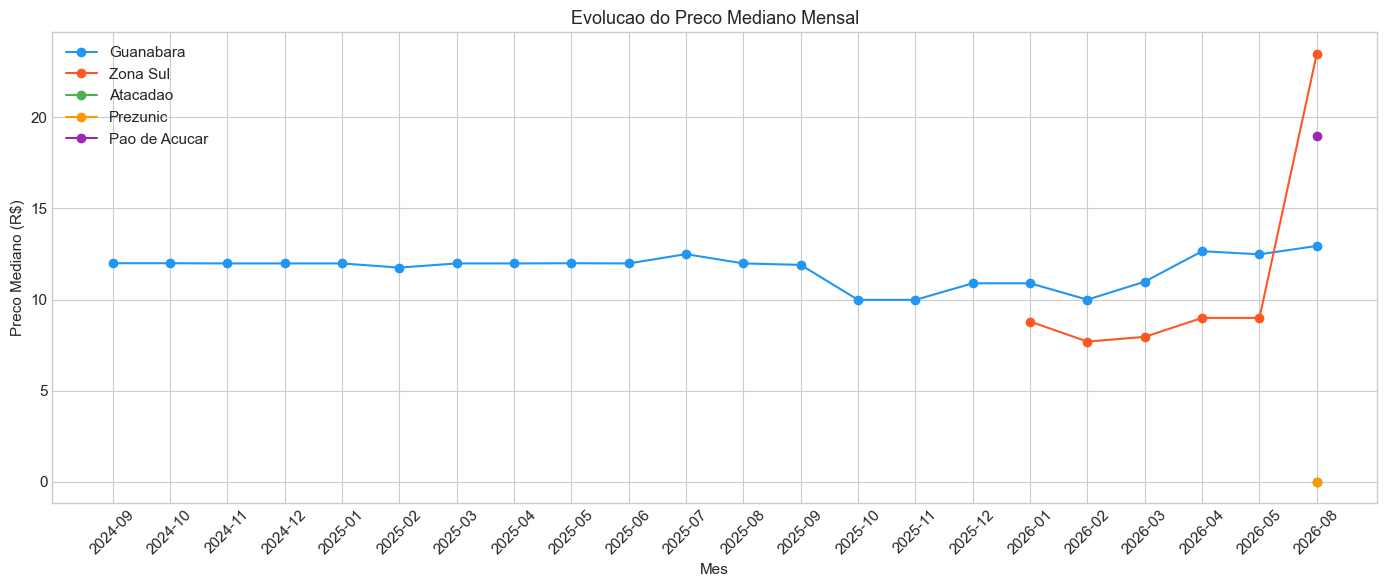

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

for nome in ['Guanabara', 'Zona Sul', 'Atacadao', 'Prezunic', 'Pao de Acucar']:
    df = todos[todos['supermercado'] == nome]
    if len(df) == 0:
        continue
    df_m = df.groupby(df['data'].dt.to_period('M'))['preco'].agg(['mean', 'median'])
    ax.plot(df_m.index.astype(str), df_m['median'], marker='o', label=nome, color=cores[nome])

ax.set_title('Evolucao do Preco Mediano Mensal')
ax.set_xlabel('Mes')
ax.set_ylabel('Preco Mediano (R$)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Top 10 Produtos por Supermercado

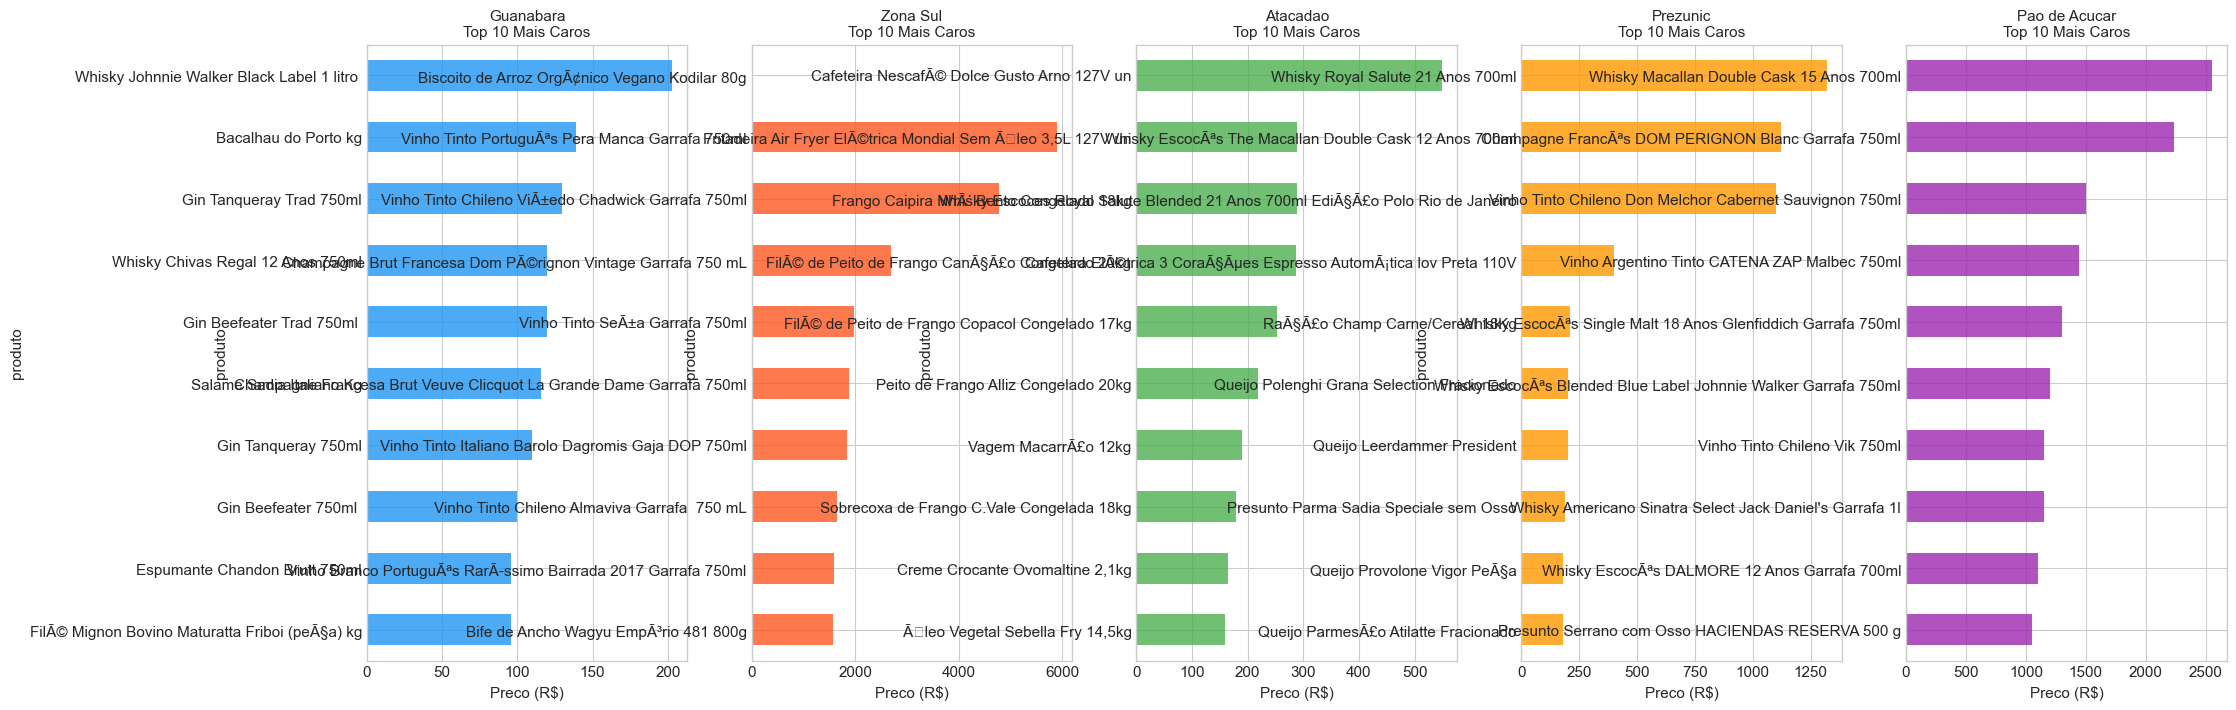

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(24, 8))

for idx, nome in enumerate(['Guanabara', 'Zona Sul', 'Atacadao', 'Prezunic', 'Pao de Acucar']):
    ax = axes[idx]
    df = todos[todos['supermercado'] == nome]
    if len(df) == 0:
        ax.set_visible(False)
        continue
    top = df.groupby('produto')['preco'].max().sort_values(ascending=True).tail(10)
    top.plot(kind='barh', ax=ax, color=cores[nome], alpha=0.8)
    ax.set_title(f'{nome}\nTop 10 Mais Caros', fontsize=11)
    ax.set_xlabel('Preco (R$)')

plt.tight_layout()
plt.show()

## 7. Analise por Setor/Categoria (Guanabara)

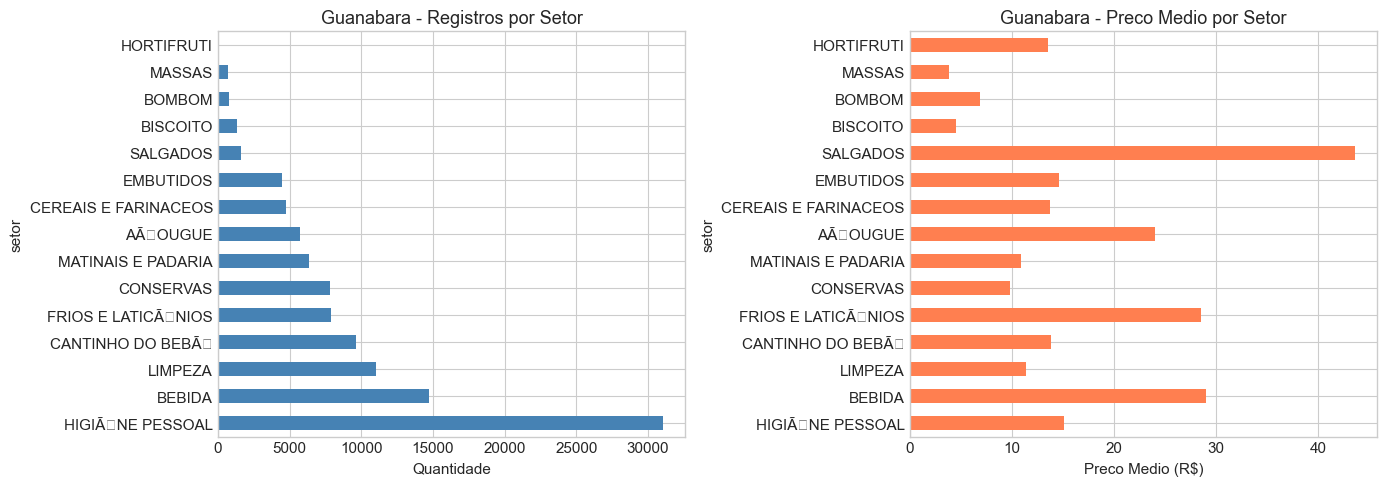

In [9]:
if 'setor' in guanabara.columns:
    setores = guanabara.groupby('setor').agg(
        qtd=('produto', 'count'),
        produtos=('produto', 'nunique'),
        preco_medio=('preco', 'mean'),
        preco_mediana=('preco', 'median')
    ).sort_values('qtd', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    setores['qtd'].plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title('Guanabara - Registros por Setor')
    axes[0].set_xlabel('Quantidade')

    setores['preco_medio'].plot(kind='barh', ax=axes[1], color='coral')
    axes[1].set_title('Guanabara - Preco Medio por Setor')
    axes[1].set_xlabel('Preco Medio (R$)')

    plt.tight_layout()
    plt.show()

## 8. Analise por Marca (Pao de Acucar)

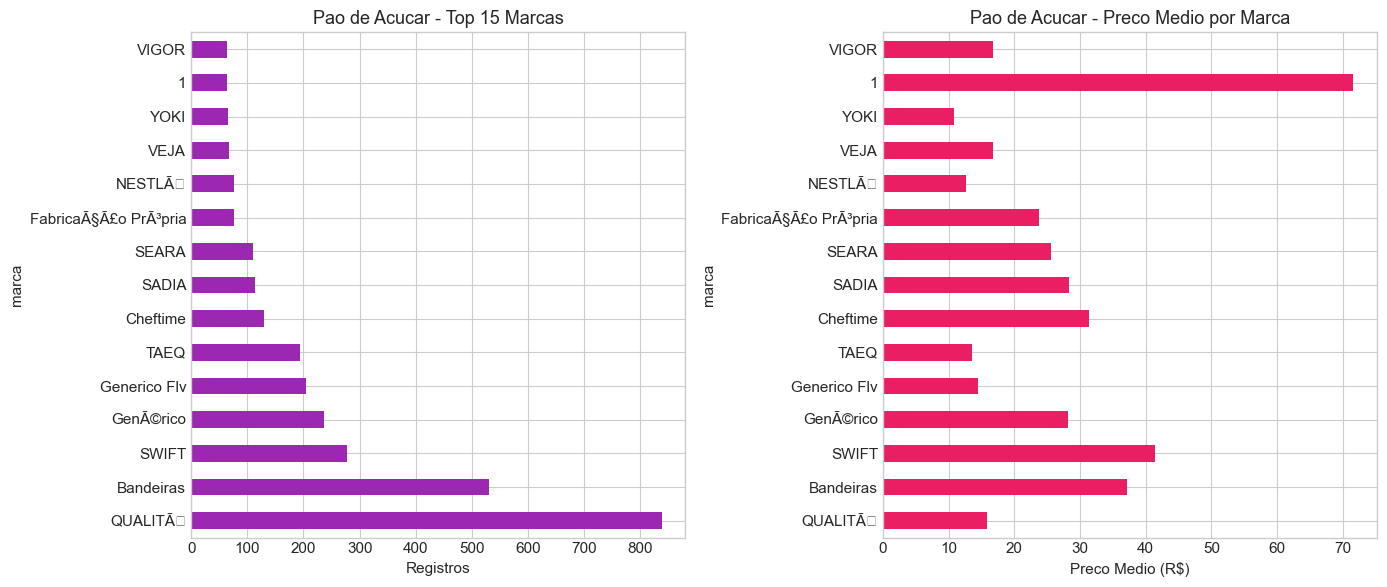

In [10]:
if len(paodeacucar) > 0 and 'marca' in paodeacucar.columns:
    marcas = paodeacucar.groupby('marca').agg(
        qtd=('produto', 'count'),
        produtos=('produto', 'nunique'),
        preco_medio=('preco', 'mean'),
        preco_mediana=('preco', 'median')
    ).sort_values('qtd', ascending=False).head(20)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    marcas['qtd'].head(15).plot(kind='barh', ax=axes[0], color='#9C27B0')
    axes[0].set_title('Pao de Acucar - Top 15 Marcas')
    axes[0].set_xlabel('Registros')

    marcas['preco_medio'].head(15).plot(kind='barh', ax=axes[1], color='#E91E63')
    axes[1].set_title('Pao de Acucar - Preco Medio por Marca')
    axes[1].set_xlabel('Preco Medio (R$)')

    plt.tight_layout()
    plt.show()

## 9. Analise por Categoria (Pao de Acucar)

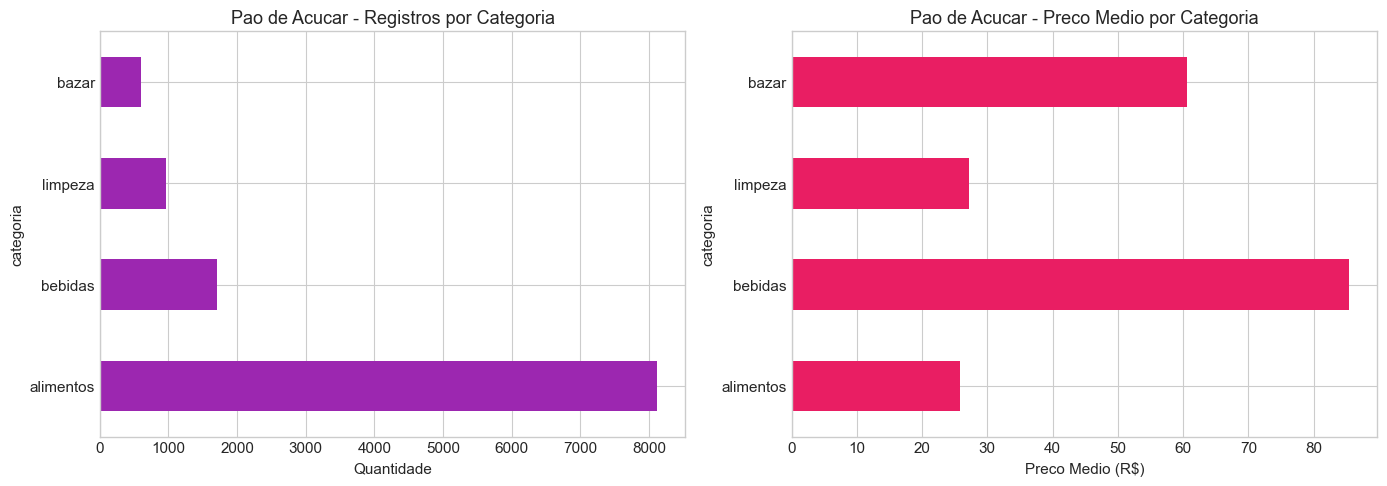

In [11]:
if len(paodeacucar) > 0 and 'categoria' in paodeacucar.columns:
    cats = paodeacucar.groupby('categoria').agg(
        qtd=('produto', 'count'),
        produtos=('produto', 'nunique'),
        preco_medio=('preco', 'mean'),
        preco_mediana=('preco', 'median')
    ).sort_values('qtd', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    cats['qtd'].plot(kind='barh', ax=axes[0], color='#9C27B0')
    axes[0].set_title('Pao de Acucar - Registros por Categoria')
    axes[0].set_xlabel('Quantidade')

    cats['preco_medio'].plot(kind='barh', ax=axes[1], color='#E91E63')
    axes[1].set_title('Pao de Acucar - Preco Medio por Categoria')
    axes[1].set_xlabel('Preco Medio (R$)')

    plt.tight_layout()
    plt.show()

## 10. Produtos com Maior Variacao de Preco

In [12]:
for nome in ['Guanabara', 'Zona Sul']:
    df = todos[(todos['supermercado'] == nome) & (todos['preco'] > 5)]
    if len(df) == 0:
        continue
    var = df.groupby('produto')['preco'].agg(['mean', 'std', 'min', 'max'])
    var['cv'] = (var['std'] / var['mean'] * 100).round(1)
    var = var.sort_values('cv', ascending=False).head(10)
    print(f'\n=== {nome} - Maior Variacao ===')
    display(var[['mean', 'min', 'max', 'cv']].style.format({
        'mean': 'R$ {:.2f}', 'min': 'R$ {:.2f}', 'max': 'R$ {:.2f}', 'cv': '{:.1f}%'
    }))


=== Guanabara - Maior Variacao ===


,mean,min,max,cv
produto,,,,
Limpador Mr. MÃºsculo Refil Cozinha 400ml c/ 20% Desc,R$ 8.10,R$ 5.99,R$ 11.90,23.8%
Creme de Pentear Lola Meu Cacho Minha Vida 500g,R$ 37.22,R$ 29.98,R$ 50.89,23.0%
Shampoo Tresemme 400ml,R$ 17.28,R$ 13.98,R$ 27.20,21.6%
"LAVA ROU PO OMO LAVAGEM PERFEITA 2,2kg",R$ 28.30,R$ 20.60,R$ 34.90,21.5%
DESINFETANTE URCA 2L,R$ 6.32,R$ 5.99,R$ 11.90,21.5%
Shampoo Clear 400ml,R$ 28.64,R$ 19.98,R$ 35.99,20.6%
Arroz Rei do Sul 5kg,R$ 18.23,R$ 11.95,R$ 25.95,20.3%
Arroz Carreteiro 5kg,R$ 23.53,R$ 15.95,R$ 30.95,20.0%
Cereal Matinal Nescau 210g,R$ 8.54,R$ 6.99,R$ 11.38,19.9%



=== Zona Sul - Maior Variacao ===


,mean,min,max,cv
produto,,,,
Farinha De Trigo Dona Benta 1kg,R$ 11.83,R$ 5.99,R$ 250.00,276.6%
CafÃ© Torrado e MoÃ­do Melitta A VÃ¡cuo 500g,R$ 33.85,R$ 26.98,R$ 250.00,70.2%
Acendedor Ãlcool Gel Montenegro 80% 430,R$ 11.99,R$ 8.99,R$ 14.99,35.4%
Tomate Italiano OrgÃ¢nico Bio Vida 500g,R$ 9.41,R$ 7.99,R$ 13.69,30.3%
Cebola OrgÃ¢nica Bio Vida 500g,R$ 9.14,R$ 7.99,R$ 12.59,25.2%
Alface Americana OrgÃ¢nica Bio Vida 180g,R$ 6.84,R$ 5.99,R$ 9.39,24.9%
Alface Crespa OrgÃ¢nica Bio Vida Processada Unidade,R$ 6.84,R$ 5.99,R$ 9.39,24.9%
Tomate Grape OrgÃ¢nico Bio Vida 180g,R$ 6.84,R$ 5.99,R$ 9.39,24.9%
Abobrinha Italiana Cariorta 1Kg,R$ 9.84,R$ 6.99,R$ 16.99,24.3%


## 11. Exportar Dados

In [13]:
cols_export = ['data', 'supermercado', 'produto', 'preco']
if 'setor' in guanabara.columns:
    guanabara['setor'] = guanabara['setor']

exportar = todos[cols_export].copy()
exportar.to_csv('dados_completos.csv', index=False, encoding='utf-8')
print(f'Exportado: {len(exportar):,} registros -> dados_completos.csv')

for nome in ['Guanabara', 'Zona Sul', 'Atacadao', 'Prezunic', 'Pao de Acucar']:
    n = len(todos[todos['supermercado'] == nome])
    if n > 0:
        print(f'  {nome}: {n:,} registros')

Exportado: 164,058 registros -> dados_completos.csv
  Guanabara: 107,994 registros
  Zona Sul: 11,742 registros
  Atacadao: 23,110 registros
  Prezunic: 9,836 registros
  Pao de Acucar: 11,376 registros
